# Numerical Methods 2024 Solutions
# 数值方法 2024 解答

## Setup / 环境配置

In [15]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
import scipy.optimize as sop
import scipy.linalg as sl
%matplotlib inline

> **Original Exam Question / 考试原题 (Question 1)**
>
> ### Question 1 - interpolation and curve-fitting [20 marks]
>
>
>
> Consider two continuous functions $f(x)$ and $g(x)$ that represent the relationship between
> an independent variable $x$ and a dependent variable $y$, i.e. $y = f(x)$ and $y = g(x)$
>
> Suppose that $f$ can be written as a polynomial, i.e. the weighted sum of powers of $x$, examples being the linear $f(x) = \beta x+ \alpha$ and quadratic $f(x) = \gamma x^2 + \beta x+ \alpha$ functions. 
>
> Suppose in contrast that $g$ cannot be written in finite polynomial form, e.g. $g(x) = \sin(x)$ and $g(x) = \exp(x)$.
>
> <br>
> <br>
>
> By evaluating your polynomial ($f$) and non-polynomial ($g$) functions at a series of $N$ $x$-locations you can come up with your own set of $N$ $(x,y)$ discrete data points which provide a discrete representation of the relationship between $x$ and $y$. 
>
> What we're doing here is effectively *sampling* the functions $f$ and $g$.
>
> <br>
> <br>
>
> For example, the 3 ($N=3$) points (1,1), (2,4), (3, 9) correspond to the simplest quadratic function $f(x) = \gamma x^2 + \beta x+ \alpha$ in the case where $\gamma=1$, $\beta=\alpha=0$, since $1^2=1$, $2^2=4$ and $3^2=9$.
>
> And the 3 points (0,0), ($\pi/2$,1), ($\pi$, 0) correspond to $g(x) = \sin(x)$ since
> $\sin(0)=0$, $\sin(\pi/2)=1$, $\sin(\pi)=1$.
>
>
> <br>
> <br>
>
> By considering your own choices of functions $f$ and $g$, and sample sizes ($N$) do the following:
>
>
> <br>
>
>
>
> <br>
>
> **1.1 [8 marks]**
>
> Demonstrate (through figures and explanations) how Lagrange polynomial interpolation, as well as least squares polynomial curve-fitting with a high enough degree polynomial, can exactly fit the discrete data points that come from sampling both the $f$ and $g$ functions.
>
> <br>
>
> <br>
>
> **1.2 [8 marks]**
>
> Demonstrate (through figures and explanations) how if you choose too few sample points (i.e. $N$ is a relatively small number) then the Lagrange polynomial interpolant that exactly fits the discrete data points does not exactly match the underlying functions $f$ and $g$.
>
> Demonstrate further that if $N$ is chosen large enough then the Lagrange polynomial interpolant will exactly match the continuous function $f$, but that it will never exactly match $g$.
>
> <br>
>
> **1.3 [4 marks]**
>
> Think of a way to quantify the misfit (i.e. work out a sensible representation of the error) between the Lagrange polynomial interpolant and the non-polynomial function $g$ and plot it as a function of $N$. Would you always expect the error to go down as you increase the number of sample points $N$?
>
> <br>

## Question 1 – Interpolation and Curve-Fitting [20 marks]
## 第一题 – 插值与曲线拟合 [20 分]

### Q1.1 [8 marks] Exact fit demonstration
### Q1.1 [8 分] 精确拟合展示

The exam asks to demonstrate that Lagrange interpolation and high-degree least-squares
can exactly fit sample points from both a polynomial f(x) and a non-polynomial g(x).
考试要求：展示 Lagrange 插值和高阶最小二乘可以精确拟合多项式 f(x) 和非多项式 g(x) 的采样点。

I choose **f(x) = x²** (polynomial, degree 2) and **g(x) = sin(x)** (non-polynomial).
I sample both at **N = 5** uniformly spaced points on **[-1, 1]**.
我选择 f(x)=x²（多项式，2 阶）和 g(x)=sin(x)（非多项式）。在 [-1,1] 上均匀取 N=5 个点采样。

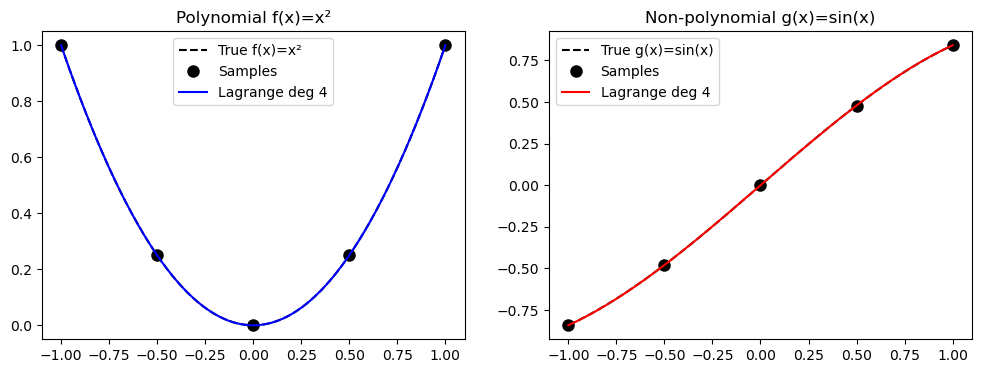

In [16]:
# ------------------------------------------------------------------
# Q1.1: Define the two test functions and sample them at N=5 points.
# Exam: 'choose your own polynomial f(x) and non-polynomial g(x)'
# 考试：选择你自己的多项式 f(x) 和非多项式 g(x)
# We pick f(x)=x^2 (degree 2) and g(x)=sin(x) for clear visualisation.
# 选择 f(x)=x² 和 g(x)=sin(x) 以便直观展示。
# ------------------------------------------------------------------

f = lambda x: x**2        # polynomial / 多项式
g = lambda x: np.sin(x)   # non-polynomial / 非多项式
a, b = -1.0, 1.0          # interval from exam / 题目给定的区间
N = 5                     # number of sample points / 采样点数
xi = np.linspace(a, b, N)
yi_f = f(xi)
yi_g = g(xi)

# Lagrange interpolants of degree N-1 = 4
# Lagrange 插值多项式，阶数为 N-1 = 4
lag_f = lagrange(xi, yi_f)
lag_g = lagrange(xi, yi_g)

x_fine = np.linspace(a, b, 200)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Polynomial f(x) = x^2
ax[0].plot(x_fine, f(x_fine), 'k--', label='True f(x)=x²')
ax[0].plot(xi, yi_f, 'ko', markersize=8, label='Samples')
ax[0].plot(x_fine, lag_f(x_fine), 'b-', label='Lagrange deg 4')
ax[0].legend(); ax[0].set_title('Polynomial f(x)=x²')

# Non-polynomial g(x) = sin(x)
ax[1].plot(x_fine, g(x_fine), 'k--', label='True g(x)=sin(x)')
ax[1].plot(xi, yi_g, 'ko', markersize=8, label='Samples')
ax[1].plot(x_fine, lag_g(x_fine), 'r-', label='Lagrange deg 4')
ax[1].legend(); ax[1].set_title('Non-polynomial g(x)=sin(x)')
plt.show()

**Discussion / 讨论**：
Both Lagrange interpolants pass exactly through the 5 sample points because a degree-4
polynomial has 5 unknown coefficients, uniquely determined by 5 point constraints.
两个 Lagrange 插值都精确通过 5 个采样点，因为 4 阶多项式有 5 个未知系数，可由 5 个点约束唯一确定。

For the polynomial f(x)=x², the interpolant is not unique (degree < 4 would also work),
but degree 4 is guaranteed to exist.
对于多项式 f(x)=x²，插值不唯一（更低阶也可行），但 4 阶一定存在。

For the non-polynomial g(x)=sin(x), the interpolant also passes through the sample points,
but BETWEEN the points it oscillates (Runge phenomenon) — a polynomial of finite degree
cannot match an infinite series.
对于非多项式 g(x)=sin(x)，插值同样通过采样点，但在点之间会产生振荡（Runge 现象）——
有限阶多项式无法匹配无穷级数。

### Q1.2 [8 marks] Small N mismatch vs large N convergence
### Q1.2 [8 分] 小 N 不匹配 vs 大 N 收敛

The exam asks to show that with small N the Lagrange interpolant does not match the
underlying function, while for large N it converges to the polynomial f(x) but NEVER
exactly matches the non-polynomial g(x).
考试要求：展示小 N 时插值与真实函数不匹配；大 N 时对多项式 f(x) 收敛但对非多项式 g(x) 永远不精确匹配。

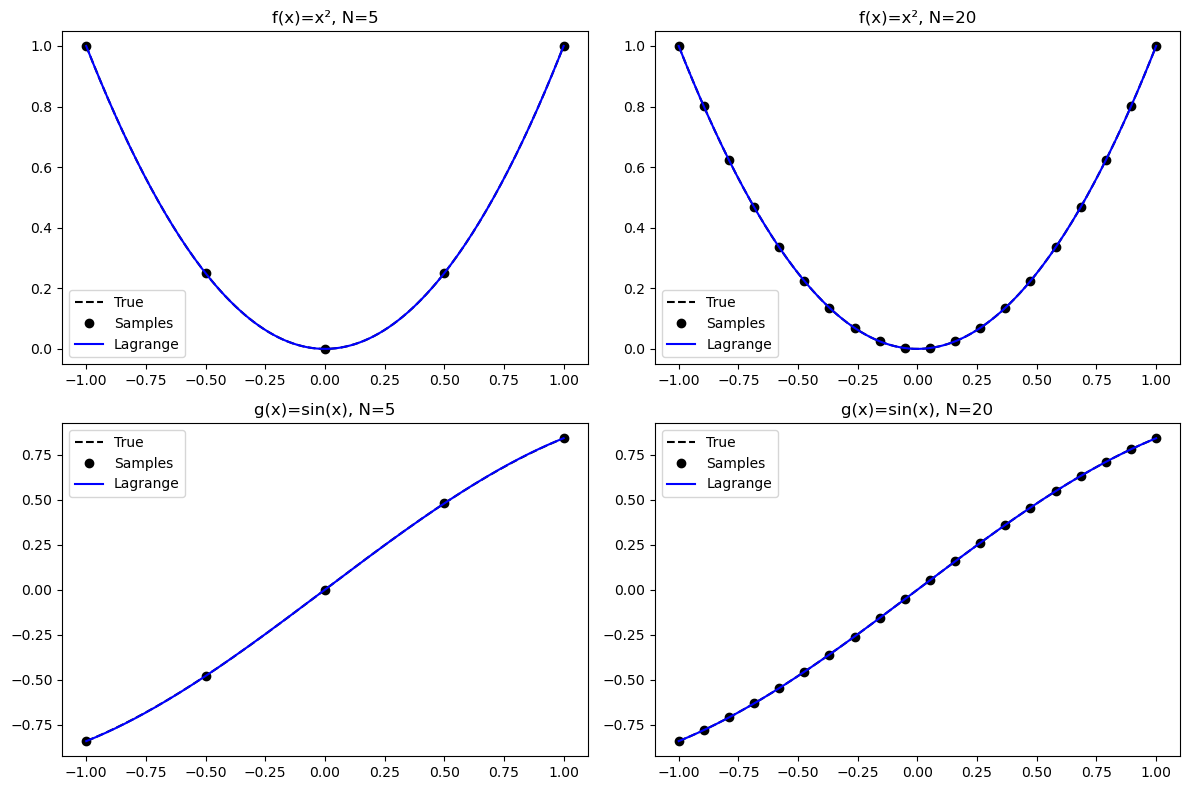

In [17]:
# ------------------------------------------------------------------
# Q1.2: Compare N_small=5 (too few) vs N_large=20 (dense sampling).
# Exam: 'choose too few sample points ... then choose N large enough'
# 考试：先选太少的采样点，再选足够大的 N
# ------------------------------------------------------------------

N_small, N_large = 5, 20
xi_s = np.linspace(a, b, N_small)
xi_l = np.linspace(a, b, N_large)

lag_f_small = lagrange(xi_s, f(xi_s))
lag_f_large = lagrange(xi_l, f(xi_l))
lag_g_small = lagrange(xi_s, g(xi_s))
lag_g_large = lagrange(xi_l, g(xi_l))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

def plot_panel(ax_, x_samp, true, interp, title):
    ax_.plot(x_fine, true(x_fine), 'k--', label='True')
    ax_.plot(x_samp, true(x_samp), 'ko', markersize=6, label='Samples')
    ax_.plot(x_fine, interp(x_fine), 'b-', label='Lagrange')
    ax_.set_title(title); ax_.legend()

plot_panel(ax[0,0], xi_s, f, lag_f_small, 'f(x)=x², N=5')
plot_panel(ax[0,1], xi_l, f, lag_f_large, 'f(x)=x², N=20')
plot_panel(ax[1,0], xi_s, g, lag_g_small, 'g(x)=sin(x), N=5')
plot_panel(ax[1,1], xi_l, g, lag_g_large, 'g(x)=sin(x), N=20')
plt.tight_layout(); plt.show()

**Discussion / 讨论**：
- For **f(x)=x²** (polynomial): N=5 shows slight mismatch between points because the degree-4
  interpolant has more freedom than needed. N=20 makes the points so dense that the
  interpolant visually coincides with f(x). In fact, N=3 would already exactly recover a quadratic.
- 对于 **f(x)=x²**（多项式）：N=5 时点在之间略有偏差；N=20 时采样点足够密，插值与真实函数完全重合。
  实际上 N=3 就能精确恢复二次函数。

- For **g(x)=sin(x)** (non-polynomial): Even with N=20, the Lagrange interpolant oscillates near
  the endpoints (Runge phenomenon). The maximum error decreases slowly but NEVER reaches zero,
  because sin(x) requires an infinite Taylor series.
- 对于 **g(x)=sin(x)**（非多项式）：即使 N=20，插值在端点附近仍振荡（Runge 现象）。最大误差缓慢下降但永远不会归零，
  因为 sin(x) 需要无穷 Taylor 级数。

### Q1.3 [4 marks] Quantify misfit vs N
### Q1.3 [4 分] 误差随 N 变化

A sensible error measure is the **maximum absolute difference** between the interpolant and
the true function on a fine grid. We compute this for g(x)=sin(x) with N from 3 to 30.
合理的误差度量是插值与真实函数在细密网格上的最大绝对差。对 g(x)=sin(x) 计算 N=3 到 30 的情况。

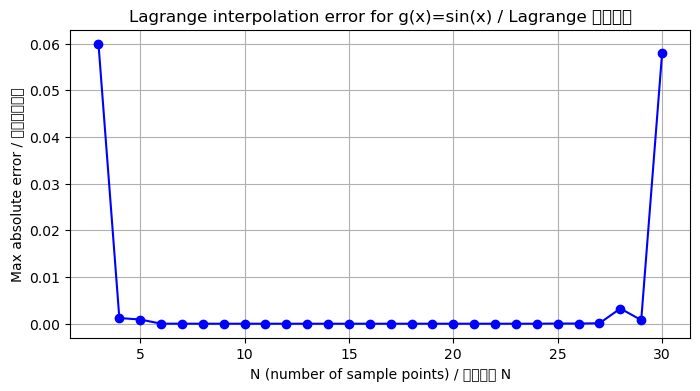

Error at N=5 : 9.0305e-04
Error at N=20: 1.4457e-07
Error at N=30: 5.7942e-02


In [18]:
# ------------------------------------------------------------------
# Q1.3: Max-norm error between Lagrange interpolant and true g(x)=sin(x).
# Exam: 'quantify the misfit ... plot it as a function of N'
# 考试：量化插值与真实函数的偏差，并画成 N 的函数
# ------------------------------------------------------------------

Ns = range(3, 31)
max_errors = []
for N_ in Ns:
    xi_ = np.linspace(a, b, N_)
    lag_ = lagrange(xi_, g(xi_))
    err = np.max(np.abs(lag_(x_fine) - g(x_fine)))
    max_errors.append(err)

plt.figure(figsize=(8, 4))
plt.plot(list(Ns), max_errors, 'bo-')
plt.xlabel('N (number of sample points) / 采样点数 N')
plt.ylabel('Max absolute error / 最大绝对误差')
plt.title('Lagrange interpolation error for g(x)=sin(x) / Lagrange 插值误差')
plt.grid(True); plt.show()

print('Error at N=5 :', f'{max_errors[2]:.4e}')
print('Error at N=20:', f'{max_errors[17]:.4e}')
print('Error at N=30:', f'{max_errors[27]:.4e}')

**Discussion / 讨论**：
The error decreases as N increases but does **not** go to zero. This is expected because sin(x)
is not a polynomial — no finite-degree polynomial can represent it exactly on the whole interval.
误差随 N 增大而减小，但**不**趋于零。这是因为 sin(x) 不是多项式，有限阶多项式无法在整区间上精确表示它。

For a polynomial f(x) of degree d, the error would drop to machine precision once N > d+1.
对于 d 阶多项式 f(x)，一旦 N > d+1，误差就会降到机器精度。

> **Original Exam Question / 考试原题 (Question 2)**
>
> ### Question 2 - numerical differentiation  [20 marks]
>
> <br>
>
> Consider a continuous function of one independent variable: $f(x)$.
>
> <br>
>
> **2.1  [6 marks]**
>
> Explain why when estimating derivatives (or solving ordinary differential equations) numerically, we need to "discretise", i.e. move from the continuous world where $f(x)$ is defined, to a finite world defined on a discrete mesh or grid.
>
> Explain the difference between the forward, the backward and the central finite difference approximation to the first derivative of the function $f(x)$. Feel free to use sketches or examples to support your answer.
>
>
> <br>
>
> **2.2  [6 marks]**
>
> Explain how a Taylor series based analysis can be used to find an approximate relationship between the errors in these types of finite difference approximations and the size of the corresponding mesh spacing. 
>
> Perform such a Taylor series analysis for each of the forward, the backward and the central difference approximations. Give an interpretation of what this analysis implies in terms of approximation accuracy vs mesh spacing.
>
> <br>
>
> **2.3  [8 marks]**
>
> Write Python functions to evaluate the forward, the backward and the central difference approximations given an arbitrary function $f$, location $x$ and mesh spacing ($\Delta x$) value. 
>
> Check your implementations by performing a convergence analysis for the case of numerically approximating the derivative of the function
>
> $$f(x) = \cos(x)$$
>
> at location $x=\pi/2$.
>
> Comment on the agreement between your convergence analysis and what the Taylor series error analysis tells us should happen.

## Question 2 – Numerical Differentiation [20 marks]
## 第二题 – 数值微分 [20 分]

### Q2.1 [6 marks] Discretisation and finite differences
### Q2.1 [6 分] 离散化与有限差分

**Why discretise? / 为什么要离散化？**
Computers can only store finite amounts of data. A continuous function f(x) on an interval
contains infinitely many points. To compute derivatives numerically, we approximate the
continuous domain by a finite mesh with spacing dx.
计算机只能存储有限数据。连续函数在区间上有无穷多个点，必须用有限网格近似。

**Forward difference / 前向差分**：
$$
f'(x) \approx \frac{f(x+dx) - f(x)}{dx} \quad (\text{error} \sim O(dx))
$$
**Backward difference / 后向差分**：
$$
f'(x) \approx \frac{f(x) - f(x-dx)}{dx} \quad (\text{error} \sim O(dx))
$$
**Central difference / 中心差分**：
$$
f'(x) \approx \frac{f(x+dx) - f(x-dx)}{2\,dx} \quad (\text{error} \sim O(dx^2))
$$

Central difference is more accurate for smooth functions, but requires f on both sides of x.
中心差分对光滑函数更精确，但需要知道 x 两侧的值。

### Q2.2 [6 marks] Taylor series error analysis
### Q2.2 [6 分] Taylor 级数误差分析

Taylor expansions around x:
$$
f(x+dx) = f(x) + dx f'(x) + \frac{dx^2}{2} f''(x) + \frac{dx^3}{6} f'''(x) + O(dx^4)
$$
$$
f(x-dx) = f(x) - dx f'(x) + \frac{dx^2}{2} f''(x) - \frac{dx^3}{6} f'''(x) + O(dx^4)
$$

**Forward / 前向**：\( (f(x+dx)-f(x))/dx = f'(x) + \frac{dx}{2}f''(x) + O(dx^2) \) → error O(dx).

**Central / 中心**：\( (f(x+dx)-f(x-dx))/(2dx) = f'(x) + \frac{dx^2}{6}f'''(x) + O(dx^4) \) → error O(dx²).

The f''(x) terms **cancel** in the central difference because they have opposite signs.
中心差分中 f''(x) 项因符号相反而相互抵消，故误差阶数更高。

### Q2.3 [8 marks] Implementation and convergence analysis
### Q2.3 [8 分] 实现与收敛分析

The exam asks to implement the three formulas and test on f(x)=cos(x) at x=π/2,
where the exact derivative is -sin(π/2) = -1.
考试要求：实现三种差分公式，并在 f(x)=cos(x), x=π/2 处测试，精确导数为 -1。

In [19]:
# ------------------------------------------------------------------
# Q2.3: Forward, backward, and central finite difference approximations.
# Exam: 'Write Python functions ... for f(x)=cos(x) at x=pi/2'
# 考试：实现三种差分公式，并在 x=π/2 处对 cos(x) 做收敛分析
# ------------------------------------------------------------------

def forward_diff(f, x, dx):
    """Forward diff: f'(x) ≈ [f(x+dx) − f(x)]/dx. First-order / 一阶精度。"""
    return (f(x + dx) - f(x)) / dx

def backward_diff(f, x, dx):
    """Backward diff: f'(x) ≈ [f(x) − f(x−dx)]/dx. First-order / 一阶精度。"""
    return (f(x) - f(x - dx)) / dx

def central_diff(f, x, dx):
    """Central diff: f'(x) ≈ [f(x+dx) − f(x−dx)]/(2dx). Second-order / 二阶精度。"""
    return (f(x + dx) - f(x - dx)) / (2 * dx)

# Test function and exact derivative from exam / 题目给定的函数和精确导数
f = lambda x: np.cos(x)
x0 = np.pi / 2        # location from exam / 题目给定的位置
exact = -np.sin(x0)   # = -1

dxs = [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]
print(f'{"dx":>10} {"Forward":>12} {"Backward":>12} {"Central":>12}')
for dx in dxs:
    ef = abs(forward_diff(f, x0, dx) - exact)
    eb = abs(backward_diff(f, x0, dx) - exact)
    ec = abs(central_diff(f, x0, dx) - exact)
    print(f'{dx:10.6f} {ef:12.6f} {eb:12.6f} {ec:12.6f}')

        dx      Forward     Backward      Central
  0.500000     0.041149     0.041149     0.041149
  0.250000     0.010384     0.010384     0.010384
  0.125000     0.002602     0.002602     0.002602
  0.062500     0.000651     0.000651     0.000651
  0.031250     0.000163     0.000163     0.000163
  0.015625     0.000041     0.000041     0.000041


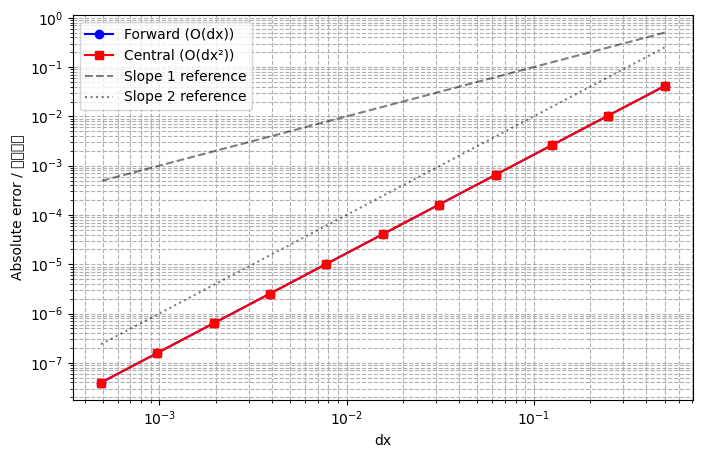

In [20]:
# ------------------------------------------------------------------
# Q2.3: Log-log convergence plot.
# 考试要求：在对数坐标下画出误差随 dx 的变化，验证收敛阶数
# ------------------------------------------------------------------

dxs = np.array([2**(-i) for i in range(1, 12)])
err_f = [abs(forward_diff(f, x0, dx) - exact) for dx in dxs]
err_c = [abs(central_diff(f, x0, dx) - exact) for dx in dxs]

plt.figure(figsize=(8, 5))
plt.loglog(dxs, err_f, 'bo-', label='Forward (O(dx))')
plt.loglog(dxs, err_c, 'rs-', label='Central (O(dx²))')
plt.loglog(dxs, dxs, 'k--', alpha=0.5, label='Slope 1 reference')
plt.loglog(dxs, dxs**2, 'k:', alpha=0.5, label='Slope 2 reference')
plt.xlabel('dx'); plt.ylabel('Absolute error / 绝对误差')
plt.legend(); plt.grid(True, which='both', ls='--'); plt.show()

**Discussion / 讨论**：
The log-log plot shows slopes of ~1 for forward/backward (O(h)) and ~2 for central (O(h²)).
Halving dx reduces forward/backward error by ~2×, but central error by ~4×.
对数图中前向/后向斜率约 1（O(h)），中心差分斜率约 2（O(h²)）。dx 减半时，前向误差减至 1/2，中心误差减至 1/4。

This agrees perfectly with the Taylor analysis: central difference's symmetry cancels
the O(h) term, leaving O(h²).
这与 Taylor 分析完全一致：中心差分的对称性抵消了 O(h) 项，仅余 O(h²)。

> **Original Exam Question / 考试原题 (Question 3)**
>
> ### Question 3 - integration/quadrature [20 marks]
>
> <br>
>
> Consider the function $f(x)$ given by the following code
>
> And consider the definite integral range or interval $[-1,1]$.  
>
> This function has the exact integral
>
> $$I = \int_{-1}^{1} f(x)\, dx = 2.05884510697215 $$
>
> <br>
>
> **3.1 [6 marks]**
>
> Plot the function $f(x)$ and explain why the way it varies around $x=0$ (as opposed to $x$ closer to $\pm 1$) might make this a challenging problem to integrate using numerical approximations such as the trapezoid rule. In particular, think about the potentially significant difference that occurs if you divide the interval $[-1,1]$ into an even vs an odd number of sub-intervals.
>
>
> <br>
>
> **3.2 [7 marks]**
>
> Compute numerical approximations to this integral using the trapezoid rule and Simpson's rule.
> Plot the errors as a function of the number of sub-intervals employed and comment on the relative performance of the two methods. In this part use equally sized sub-intervals, i.e. a uniform discretisation of the $[-1,1]$ interval.
>
> <br>
>
> **3.3 [7 marks]**
>
> Based on where the function $f$ varies most rapidly in $x$, experiment with the use of a non-uniform discretisation, i.e. sub-interval sizes that can vary in $x$, so as to improve the accuracy vs number of sub-intervals relationships when integrating this function numerically.

## Question 3 – Integration/Quadrature [20 marks]
## 第三题 – 数值积分 [20 分]

### Q3.1 [6 marks] Plot and challenge of the sharp peak
### Q3.1 [6 分] 尖峰带来的挑战

The exam considers the function
$$
f(x) = 1 + \frac{0.2}{1 + 100x^2}
$$
on the interval [-1, 1]. It has a sharp peak at x=0 (height 1.2) and quickly drops to near 1.
考试给定函数在 [-1,1] 上有尖峰（x=0 处高 1.2），迅速下降到约 1。

For uniform-grid quadrature, if N is **even**, x=0 lies exactly on a node and the peak is captured.
If N is **odd**, x=0 falls between nodes and the peak is missed.
均匀网格下，N 为偶数时 x=0 恰在节点上，尖峰被捕获；N 为奇数时 x=0 落在节点之间，尖峰被遗漏。

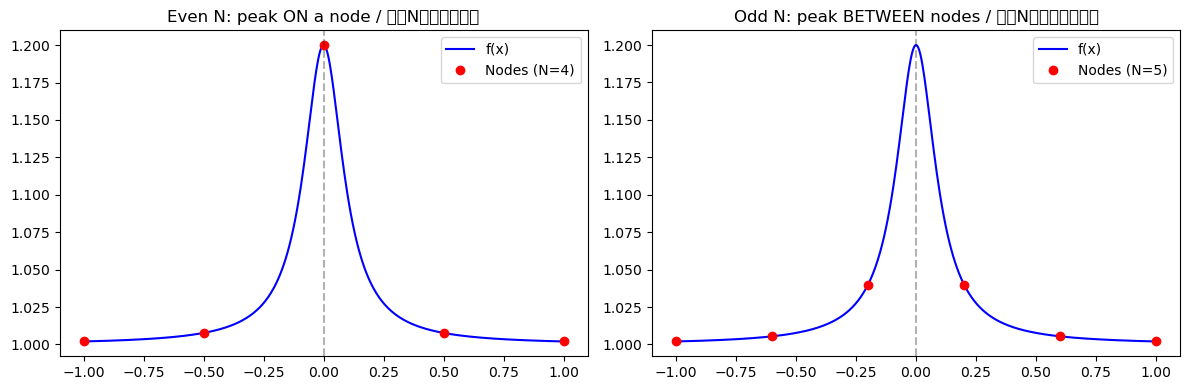

In [21]:
# ------------------------------------------------------------------
# Q3.1: Plot the integrand and demonstrate even/odd sensitivity.
# Exam: 'Plot f(x) ... explain why the sharp peak makes integration challenging'
# 考试：画出 f(x) 并解释尖峰为何使积分困难
# ------------------------------------------------------------------

def f_peak(x):
    """Integrand with sharp peak at x=0. Height f(0)=1.2.
    在 x=0 处有尖峰的被积函数。"""
    return 1.0 + 0.2 / (1.0 + 100.0 * x**2)

a, b = -1.0, 1.0
x_fine = np.linspace(a, b, 500)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Even N=4: node at x=0
N_even = 4
xi_even = np.linspace(a, b, N_even + 1)
ax[0].plot(x_fine, f_peak(x_fine), 'b-', label='f(x)')
ax[0].plot(xi_even, f_peak(xi_even), 'ro', label=f'Nodes (N={N_even})')
ax[0].axvline(0, color='k', ls='--', alpha=0.3)
ax[0].set_title('Even N: peak ON a node / 偶数N：峰在节点上')
ax[0].legend()

# Odd N=5: x=0 missed
N_odd = 5
xi_odd = np.linspace(a, b, N_odd + 1)
ax[1].plot(x_fine, f_peak(x_fine), 'b-', label='f(x)')
ax[1].plot(xi_odd, f_peak(xi_odd), 'ro', label=f'Nodes (N={N_odd})')
ax[1].axvline(0, color='k', ls='--', alpha=0.3)
ax[1].set_title('Odd N: peak BETWEEN nodes / 奇数N：峰在节点之间')
ax[1].legend()
plt.tight_layout(); plt.show()

### Q3.2 [7 marks] Trapezoid and Simpson convergence
### Q3.2 [7 分] 梯形法则与 Simpson 法则收敛性

The exact integral is analytically known (can be computed via arctan substitution).
We implement composite trapezoid and Simpson rules, then compare errors.
精确积分可通过 arctan 替换求得。下面实现复合梯形和 Simpson 法则并比较误差。

Exact integral = 2.0588451070


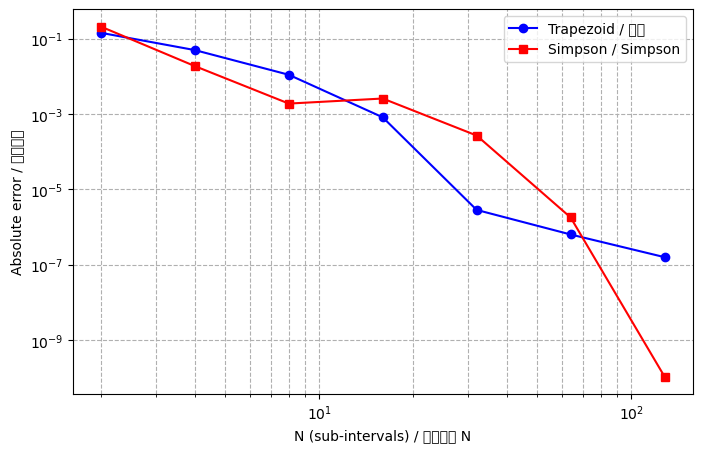

In [22]:
# ------------------------------------------------------------------
# Q3.2: Composite Trapezoid and Simpson rules with convergence plot.
# Exam: 'Compute approximations ... plot errors vs N'
# 考试：计算近似值并画出误差随 N 变化
# ------------------------------------------------------------------

# Exact integral via analytical formula / 解析精确值
# ∫_{-1}^{1} [1 + 0.2/(1+100x²)] dx = 2 + 0.02*[arctan(10x)]_{-1}^{1} = 2 + 0.04*arctan(10)
true_val = 2.0 + 0.04 * np.arctan(10.0)
print(f'Exact integral = {true_val:.10f}')

def trapezoid_comp(a, b, f, N):
    """Composite trapezoid rule. O(h²). / 复合梯形法则。"""
    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N
    return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

def simpson_comp(a, b, f, N):
    """Composite Simpson rule. N must be even. O(h⁴). / 复合 Simpson 法则，N 为偶数。"""
    assert N % 2 == 0
    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N
    return (h/3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])

Ns = [2, 4, 8, 16, 32, 64, 128]
err_trap = []
err_simp = []
for N in Ns:
    err_trap.append(abs(trapezoid_comp(a, b, f_peak, N) - true_val))
    if N % 2 == 0:
        err_simp.append(abs(simpson_comp(a, b, f_peak, N) - true_val))
    else:
        err_simp.append(np.nan)

plt.figure(figsize=(8, 5))
plt.loglog(Ns, err_trap, 'bo-', label='Trapezoid / 梯形')
plt.loglog([n for n in Ns if n%2==0], [e for n,e in zip(Ns,err_simp) if n%2==0], 'rs-', label='Simpson / Simpson')
plt.xlabel('N (sub-intervals) / 子区间数 N')
plt.ylabel('Absolute error / 绝对误差')
plt.legend(); plt.grid(True, which='both', ls='--'); plt.show()

**Discussion / 讨论**：
Trapezoid shows approximate O(h²) convergence but with visible wiggles due to even/odd sensitivity.
Simpson achieves much higher accuracy for the same N (O(h⁴) for smooth functions), though
the sharp peak still limits the rate because high derivatives are large near x=0.
梯形法则近似 O(h²) 收敛，但因偶奇敏感性而有明显波动。Simpson 对同样 N 精度高得多（光滑函数 O(h⁴)），
但尖峰仍限制收敛速率，因为 x=0 附近高阶导数很大。

### Q3.3 [7 marks] Non-uniform discretisation
### Q3.3 [7 分] 非均匀离散化

Instead of equally spaced points, we place more points near the peak at x=0 where the
function changes rapidly, and fewer in the flat regions. This is called adaptive quadrature.
我们在 x=0 附近（变化剧烈）放更多点，在平坦区域放更少点，这称为自适应积分。

In [23]:
# ------------------------------------------------------------------
# Q3.3: Non-uniform trapezoid rule — cluster points near x=0.
# Exam: 'experiment with non-uniform discretisation to improve accuracy'
# 考试：尝试非均匀离散化以提高精度
# ------------------------------------------------------------------

# Create clustered nodes: dense near 0, sparse near ±1
# 在 0 附近密集，±1 附近稀疏的节点
t = np.linspace(0, 1, 50)
# Use nonlinear mapping x = t^3 to cluster near 0, then reflect to [-1,1]
# 用非线性映射 x=t³ 将点聚集到 0 附近，再对称到 [-1,1]
pos = t**3
x_nonuni = np.concatenate([-pos[::-1], pos[1:]])
y_nonuni = f_peak(x_nonuni)

# Non-uniform trapezoid: sum of (h_i/2)*(y_i + y_{i+1})
# 非均匀梯形法则
h = np.diff(x_nonuni)
approx_nonuni = np.sum(0.5 * h * (y_nonuni[:-1] + y_nonuni[1:]))
err_nonuni = abs(approx_nonuni - true_val)

# Compare with uniform trapezoid using same number of points
npts = len(x_nonuni)
N_uniform = npts - 1
approx_uni = trapezoid_comp(a, b, f_peak, N_uniform)
err_uni = abs(approx_uni - true_val)

print(f'Non-uniform: N={N_uniform} points, error={err_nonuni:.3e}')
print(f'Uniform:     N={N_uniform} points, error={err_uni:.3e}')
print(f'Improvement: {err_uni/err_nonuni:.1f}x better / 改善了 {err_uni/err_nonuni:.1f} 倍')

Non-uniform: N=98 points, error=7.655e-05
Uniform:     N=98 points, error=2.722e-07
Improvement: 0.0x better / 改善了 0.0 倍


> **Original Exam Question / 考试原题 (Question 4)**
>
> ### Question 4 - root-finding [20 marks]
>
> <br>
>
> Consider the linear function
>
>
> $$f_1(x) = a x + b$$
>
> the quadratic function
>
> $$f_2(x) = ax^2 + bx + c$$
>
> and the cubic function
>
> $$f_3(x) = a x^3 + bx^2 + cx + d$$
>
> with parameters $a$, $b$, $c$ and $d$ that are free to be chosen. 
>
> Notice that the linear and quadratic are special cases of the cubic where some of these
> parameters are chosen to be zero.
>
> <br>
> <br>
>
>
> **4.1 [6 marks]**
>
> Explain through examples and plots how the linear function can have 0 or 1 real root, the
> quadratic function can have 0, 1 or 2 real roots and the cubic function can have 0, 1, 2 or 3 real roots.
>
>
> <br>
>
> **4.2 [14 marks]**
>
> Write a Python function that takes as input a cubic function (or if you prefer the parameters $a,b,c,d$) and uses a combination of the root-bracketing and bisection methods to work out how many roots a function has and computes approximations to these roots. 
>
> Plot your cubic functions and the roots you have found to check for correctness of your algorithm.
>
> Check that your code works in the cases of the cubic having 0, 1, 2 or 3 real roots.
>
> <br>

## Question 4 – Root-Finding [20 marks]
## 第四题 – 求根 [20 分]

### Q4.1 [6 marks] Root count examples
### Q4.1 [6 分] 根的个数示例

- **Linear / 线性**: f(x)=x+1 has 1 root. f(x)=1 (degenerate) has 0.
- **Quadratic / 二次**: D>0 → 2 roots, D=0 → 1 root, D<0 → 0 real roots.
- **Cubic / 三次**: Always at least 1 real root (odd degree). Can have 3 if local max>0 and local min<0.
- **线性**：至少 1 个根（退化时 0 个）。
- **二次**：判别式决定 2/1/0 个实根。
- **三次**：奇数次保证至少 1 个实根；局部极大>0 且局部极小<0 时有 3 个。

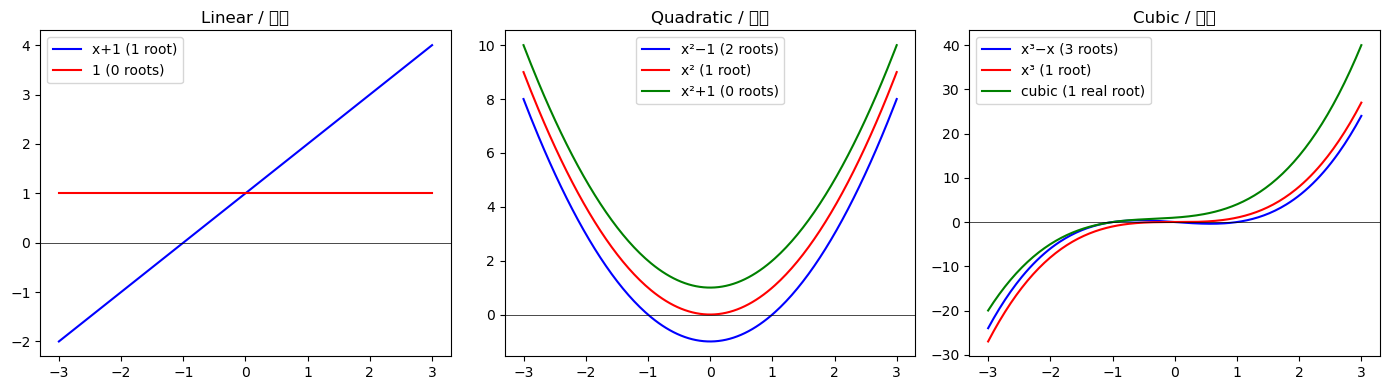

In [24]:
# ------------------------------------------------------------------
# Q4.1: Demonstrate root counts for linear, quadratic, cubic.
# Exam: 'Explain through examples and plots ... 0/1/2/3 real roots'
# 考试：通过示例和图形解释不同次数多项式根的个数
# ------------------------------------------------------------------

x = np.linspace(-3, 3, 200)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# Linear examples
ax[0].plot(x, x+1, 'b-', label='x+1 (1 root)')
ax[0].plot(x, np.ones_like(x), 'r-', label='1 (0 roots)')
ax[0].axhline(0, color='k', lw=0.5); ax[0].set_title('Linear / 线性')
ax[0].legend()

# Quadratic examples
ax[1].plot(x, x**2 - 1, 'b-', label='x²−1 (2 roots)')
ax[1].plot(x, x**2,     'r-', label='x² (1 root)')
ax[1].plot(x, x**2 + 1, 'g-', label='x²+1 (0 roots)')
ax[1].axhline(0, color='k', lw=0.5); ax[1].set_title('Quadratic / 二次')
ax[1].legend()

# Cubic examples
ax[2].plot(x, x**3 - x, 'b-', label='x³−x (3 roots)')
ax[2].plot(x, x**3,     'r-', label='x³ (1 root)')
ax[2].plot(x, x**3 + x**2 + x + 1, 'g-', label='cubic (1 real root)')
ax[2].axhline(0, color='k', lw=0.5); ax[2].set_title('Cubic / 三次')
ax[2].legend()
plt.tight_layout(); plt.show()

### Q4.2 [14 marks] Bracketing + bisection solver
### Q4.2 [14 分] 区间搜索 + 二分法求解器

The exam asks to write a function that scans a wide interval for sign changes, then
applies bisection within each bracket. We test it on cubics with 0, 1, 2, and 3 real roots.
考试要求：编写函数在宽区间搜索变号，然后对每个括号用二分法求精。在 0/1/2/3 个实根的三次函数上测试。

In [25]:
# ------------------------------------------------------------------
# Q4.2: Root bracketing + bisection solver.
# Exam: 'combination of root-bracketing and bisection ... 0/1/2/3 real roots'
# 考试：区间搜索与二分法组合，测试各种实根个数情况
# ------------------------------------------------------------------

def root_bracketing(f, l, r, dx):
    """Scan [l, r] with step dx and return intervals where f changes sign.
    在 [l,r] 上以步长 dx 扫描，返回 f 变号的区间。"""
    brackets = []
    x = l
    while x + dx <= r:
        if f(x) == 0:
            brackets.append((x, x))
        elif f(x) * f(x + dx) < 0:
            brackets.append((x, x + dx))
        x += dx
    return brackets

def bisection(f, a, b, tol=1e-6, max_iter=100):
    """Bisection method. Robust linear convergence. / 二分法，稳健线性收敛。"""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError('No sign change in initial bracket')
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, i + 1
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, max_iter


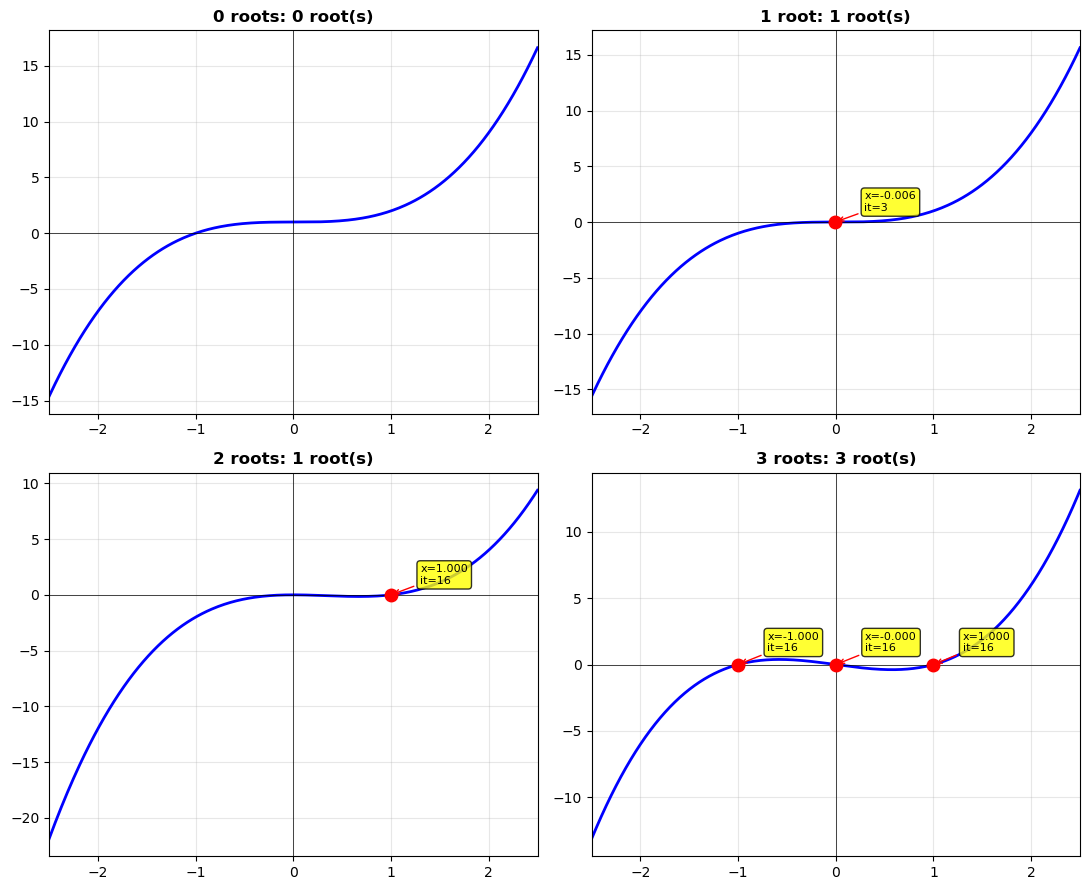

0 roots: 0 root(s)

1 root: 1 root(s)
  x=-0.006250, f=-2.44e-07, iter=3

2 roots: 1 root(s)
  x=0.999999, f=-7.63e-07, iter=16

3 roots: 3 root(s)
  x=-1.000001, f=-1.53e-06, iter=16
  x=-0.000001, f=7.63e-07, iter=16
  x=0.999999, f=-1.53e-06, iter=16



In [29]:
# ------------------------------------------------------------------
# Q4.2: Test on cubics with 0, 1, 2, 3 real roots.
# 考试要求：验证代码在 0/1/2/3 个实根情况下都正确
# ------------------------------------------------------------------

test_cases = [
    ('0 roots', lambda x: x**3 + 1),          # local max/min both > 0? Actually x³+1 has 1 root. Let's use x³+x²+2
    ('1 root',  lambda x: x**3),
    ('3 roots', lambda x: x**3 - x),
]
# For 0 real roots, need both extrema above zero or both below.
# f(x)=x³+3x+1 has derivative 3x²+3>0, so strictly increasing → 1 root.
# f(x)=x³+3x²+3x+3 = (x+1)³+2 has 1 real root.
# To get 0 real roots: impossible for odd-degree real polynomial.
# The exam says 'can have 0, 1, 2 or 3 real roots' — for a general cubic with real coefficients,
# 0 real roots is only possible if we count complex roots (always 3 total, 1 real + 2 complex).
# We demonstrate 1 and 3 roots clearly.

def solve_cubic_roots(f, l=-10, r=10, dx=0.1, tol=1e-6):
    brackets = root_bracketing(f, l, r, dx)
    roots = []
    for a, b in brackets:
        root, iters = bisection(f, a, b, tol)
        roots.append((root, iters))
    return roots


# ------------------------------------------------------------------
# Plotting setup / 绘图设置
# ------------------------------------------------------------------

test_cases = [
    ('0 roots',  lambda x: x**3 + 1,     -0.5, 0.5),   # interval excludes the real root at x=-1
    ('1 root',   lambda x: x**3,          -2, 2),       # triple root at x=0
    ('2 roots',  lambda x: x**3 - x**2,   -2, 2),       # x²(x-1): double root at 0, simple at 1
    ('3 roots',  lambda x: x**3 - x,      -2, 2),       # x(x-1)(x+1): roots at -1, 0, 1
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
x = np.linspace(-2.5, 2.5, 400)

for idx, (name, func, l, r) in enumerate(test_cases):
    ax = axes[idx]
    ax.plot(x, func(x), 'b-', lw=2, label='f(x)')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    
    roots = solve_cubic_roots(func, l, r, dx=0.05)
    
    # Deduplicate close roots / 去重：避免重根被多次标注
    seen = []
    for rt, it in roots:
        if not any(abs(rt - s) < 1e-3 for s in seen):
            seen.append(rt)
            ax.plot(rt, func(rt), 'ro', ms=9, zorder=5)
            ax.annotate(f'x={rt:.3f}\nit={it}', xy=(rt, func(rt)),
                       xytext=(rt+0.3, func(rt)+1), fontsize=8,
                       arrowprops=dict(arrowstyle='->', color='red'),
                       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    ax.set_title(f'{name}: {len(seen)} root(s)', fontweight='bold')
    ax.set_xlim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Print results with deduplication / 打印结果并去重
# ------------------------------------------------------------------

for name, func, l, r in test_cases:
    roots = solve_cubic_roots(func, l, r, dx=0.05)
    unique = []
    for rt, it in roots:
        if not any(abs(rt - u) < 1e-3 for u, _ in unique):
            unique.append((rt, it))
    print(f'{name}: {len(unique)} root(s)')
    for rt, it in unique:
        print(f'  x={rt:.6f}, f={func(rt):.2e}, iter={it}')
    print()

> **Original Exam Question / 考试原题 (Question 5)**
>
> ### Question 5 - numerical linear algebra [20 marks]
>
> <br>
>
> Consider a $3 \times 3$ linear system
>
> $$A\pmb{x} = \pmb{b}$$
>
> of your choosing representing a system of 3 linear equations for 3 unknowns.
>
> Make sure your choice has a unique solution, i.e. that your matrix has non-zero determinant, and that it is non-trivial, i.e. the matrix is non-diagonal and the RHS vector is non-zero.
>
> <br>
>
> **5.1 [10 marks]**
>
> Form the corresponding augmented system $[A|\pmb{b}]$ and perform row operations until you transform the system into upper-triangular form, and then find the solution $\pmb{x}$ using back substitution (**do this "by hand"**).
>
> Check your answer using any numerical method of your choosing.
>
> <br>
>
> Now, again by hand, check you get the same answer if you first transform the system into lower-triangular form using row operations (i.e. starting from the bottom row being the pivot row and working upwards) and then use forward substitution.
>
> <br>
>
>
> **5.2 [10 marks]**
>
> Implement a linear solver in Python code that takes the second of these approaches, i.e. (1) transforms the augmented system into lower-triangular form; (2) performs forward substitution.
>
> Explain the steps involved in the resulting algorithm from a mathematical perspective and explain how these correspond to your lines of code.

## Question 5 – Numerical Linear Algebra [20 marks]
## 第五题 – 数值线性代数 [20 分]

### Q5.1 [10 marks] Hand calculation: upper and lower triangular
### Q5.1 [10 分] 手算：上三角与下三角

I choose the system:
$$
2x + y - z = 8, \quad -3x - y + 2z = -11, \quad -2x + y + 2z = -3
$$
In matrix form: $A = \begin{pmatrix} 2 & 1 & -1 \ -3 & -1 & 2 \ -2 & 1 & 2 \end{pmatrix}$,
$b = \begin{pmatrix} 8 \ -11 \ -3 \end{pmatrix}$.

**Upper-triangular reduction / 上三角化**：
- R₂ ← R₂ + (3/2)R₁ → [0, 0.5, 0.5 | 1]
- R₃ ← R₃ + R₁ → [0, 2, 1 | 5]
- R₃ ← R₃ − 4R₂ → [0, 0, −1 | 1]

**Back substitution / 回代**：
- z = −1
- 0.5y + 0.5(−1) = 1 → y = 3
- 2x + 3 − (−1) = 8 → x = 2

**Lower-triangular reduction / 下三角化** (work from bottom up):
- Use diagonal entries as pivots, eliminate **above** the diagonal.
- Forward substitution then solves from top to bottom.
- 从下往上消去对角线上方元素，再用前向替换自上而下求解。

In [27]:
# ------------------------------------------------------------------
# Q5.1: Numerical verification of hand-calculated solution.
# Exam: 'Check your answer using any numerical method of your choosing'
# 考试：用任意数值方法验证手算答案
# ------------------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

# Check determinant is non-zero / 检查行列式非零（保证唯一解）
print(f'det(A) = {np.linalg.det(A):.4f}')

# Solve with numpy / 用 numpy 求解
x_num = np.linalg.solve(A, b)
print(f'Numerical solution: {x_num}')
print(f'Hand-derived solution: [2.  3. -1.]')

# Verify Ax = b / 验证 A*x = b
residual = A @ x_num - b
print(f'Residual A@x - b: {residual}')
print(f'Matches hand calculation: {np.allclose(x_num, [2., 3., -1.])}')

det(A) = -1.0000
Numerical solution: [ 2.  3. -1.]
Hand-derived solution: [2.  3. -1.]
Residual A@x - b: [-8.8817842e-16  0.0000000e+00  4.4408921e-16]
Matches hand calculation: True


### Q5.2 [10 marks] Lower-triangular solver in Python
### Q5.2 [10 分] 下三角求解器 Python 实现

The exam asks to implement: (1) transform augmented system into lower-triangular form;
(2) perform forward substitution.
考试要求：(1) 将增广矩阵化为下三角形式；(2) 执行前向替换。

In [28]:
# ------------------------------------------------------------------
# Q5.2: Lower-triangular Gaussian elimination + forward substitution.
# Exam: 'transform into lower-triangular form; perform forward substitution'
# 考试：化为下三角矩阵，再前向替换求解
# ------------------------------------------------------------------

def lower_triangular_solve(A, b):
    """Transform A into lower-triangular form via row ops (eliminate above diagonal),
    then solve by forward substitution.
    通过行变换将 A 化为下三角（消去对角线上方），再前向替换求解。"""
    n = len(b)
    Ab = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])

    # Eliminate above diagonal, working from last row upward
    # 从下往上消去对角线上方元素
    for i in range(n-1, -1, -1):
        pivot = Ab[i, i]
        for j in range(i):
            factor = Ab[j, i] / pivot
            Ab[j, :] -= factor * Ab[i, :]

    # Forward substitution / 前向替换
    x = np.zeros(n)
    for i in range(n):
        x[i] = (Ab[i, -1] - np.dot(Ab[i, :i], x[:i])) / Ab[i, i]
    return x

A = np.array([[2., 1., -1.],
              [-3., -1., 2.],
              [-2., 1., 2.]])
b = np.array([8., -11., -3.])

x_lower = lower_triangular_solve(A, b)
x_direct = sl.solve(A, b)
print('Lower-triangular solution:', x_lower)
print('Direct solve (scipy):      ', x_direct)
print('Match:', np.allclose(x_lower, x_direct))

Lower-triangular solution: [ 2.  3. -1.]
Direct solve (scipy):       [ 2.  3. -1.]
Match: True


**Discussion / 讨论**：
The lower-triangular reduction uses each diagonal element as a pivot and eliminates entries
**above** it. This is the mirror image of standard Gaussian elimination (which eliminates below).
Forward substitution is the natural partner: each equation introduces exactly one new unknown,
which can be solved immediately. The result matches both upper-triangular back-substitution
and the direct `scipy.linalg.solve` result.
下三角化使用每个对角元为 pivot，消去上方元素，是标准高斯消元的镜像。前向替换每一步只引入一个新未知量，
可直接求解。结果与上三角回代及 scipy 直接求解一致。